# EDA Enriquecida — Base de Segmentação de Clientes (Alimentos & Bebidas)

**Objetivo:** Análise exploratória detalhada para preparar a etapa de limpeza e suportar um projeto de *segmentação de clientes*. O notebook usa o dicionário de dados fornecido e gera análises específicas por variáveis demográficas, comportamento de compra, fidelidade e risco de churn.


In [2]:
# 1) Importação e configuração inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 5)

print('Bibliotecas importadas')



Bibliotecas importadas


In [3]:
# 1.1) Carregamento do dataset

df = pd.read_csv(r"BD/base_segmentacao_clientes_600k.csv")
# visualizar
df.head()

,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,valor_compra,frequencia_compras,score_fidelidade,data_ultima_compra,método_pagamento,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
0,CLI_000001,Bruna Carvalho Pereira,Outro,25,solteiro,1139.54,Rio de Janeiro,Rio de Janeiro,loja física,carnes,103.12,0.4,0.0,2024-12-28,débito,1,12.6,Sim,Sim,3.2,loja física,0.640,11.0,D,tablet
1,CLI_000002,Antônia Nascimento Martins,F,55,divorciado,1805.82,Caruaru,Pernambuco,site,cerveja,63.79,0.9,9.5,2024-12-10,débito,6,21.2,Não,Sim,3.6,site,0.529,11.2,D,tablet
2,CLI_000003,Pedro Dias Lima,M,53,divorciado,1861.71,Juazeiro,Bahia,loja física,snack,291.10,1.0,3.0,2024-11-25,boleto,3,9.5,Não,Não,9.0,loja física,0.584,3.3,D,desktop
3,CLI_000004,Patrícia Oliveira Alves,Outro,77,solteiro,2684.55,Guarulhos,São Paulo,loja física,cosmético,65.00,1.9,24.5,2024-12-27,Pix,9,19.4,Sim,Sim,7.8,loja física,0.449,12.3,C2,desktop
4,CLI_000005,Andréa Lopes Oliveira,Outro,74,divorciado,3996.93,Cidade_83,Rondônia,app,frutas,63.93,2.5,25.5,2024-12-24,débito,3,10.7,Não,Não,6.8,app,0.387,4.1,C1,mobile


In [5]:
# Contagem básica
num_linhas = df.shape[0]
num_colunas = df.shape[1]

print(f"Total de linhas: {num_linhas}")
print(f"Total de colunas: {num_colunas}")

Total de linhas: 600000
Total de colunas: 25


In [6]:
# 2) Inspeção inicial
print('Shape:', df.shape)
print('\nTipos de dados:')
df.info()

# Contagem e percentual de nulos
print('\nContagem de nulos por coluna:')
total_linhas = len(df)
missing = df.isnull().sum()
missing

#missing = missing[missing > 0].sort_values(ascending=False)


# Criar DataFrame com total e percentual
missing_df = pd.DataFrame({
    'Total de Nulos': missing,
    'Percentual (%)': (missing / (total_linhas) * 100).round(2)# Usar total_linhas
})

valor_total= missing_df['Total de Nulos'].sum()
print("O valor total é:", valor_total)

porcetagem_total = (valor_total/(total_linhas*len(df.columns)))# Usar total linhas e total colunas

print("O Porcetagem de nulos :", porcetagem_total)


print('\nDuplicatas totais:', df.duplicated().sum())

print('\nExemplo de 5 registros:')
display(df.head())


Shape: (600000, 25)

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id_cliente                     600000 non-null  object 
 1   nome_cliente                   600000 non-null  object 
 2   sexo                           600000 non-null  object 
 3   idade                          600000 non-null  int64  
 4   estado_civil                   600000 non-null  object 
 5   renda_mensal                   594171 non-null  float64
 6   cidade                         594052 non-null  object 
 7   estado                         600000 non-null  object 
 8   canal_compra                   593993 non-null  object 
 9   categoria_produto              593966 non-null  object 
 10  valor_compra                   594096 non-null  float64
 11  frequencia_compras             593974 non-null  float6

,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,valor_compra,frequencia_compras,score_fidelidade,data_ultima_compra,método_pagamento,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
0,CLI_000001,Bruna Carvalho Pereira,Outro,25,solteiro,1139.54,Rio de Janeiro,Rio de Janeiro,loja física,carnes,103.12,0.4,0.0,2024-12-28,débito,1,12.6,Sim,Sim,3.2,loja física,0.640,11.0,D,tablet
1,CLI_000002,Antônia Nascimento Martins,F,55,divorciado,1805.82,Caruaru,Pernambuco,site,cerveja,63.79,0.9,9.5,2024-12-10,débito,6,21.2,Não,Sim,3.6,site,0.529,11.2,D,tablet
2,CLI_000003,Pedro Dias Lima,M,53,divorciado,1861.71,Juazeiro,Bahia,loja física,snack,291.10,1.0,3.0,2024-11-25,boleto,3,9.5,Não,Não,9.0,loja física,0.584,3.3,D,desktop
3,CLI_000004,Patrícia Oliveira Alves,Outro,77,solteiro,2684.55,Guarulhos,São Paulo,loja física,cosmético,65.00,1.9,24.5,2024-12-27,Pix,9,19.4,Sim,Sim,7.8,loja física,0.449,12.3,C2,desktop
4,CLI_000005,Andréa Lopes Oliveira,Outro,74,divorciado,3996.93,Cidade_83,Rondônia,app,frutas,63.93,2.5,25.5,2024-12-24,débito,3,10.7,Não,Não,6.8,app,0.387,4.1,C1,mobile


Colunas removidas pois nao faz parte do projeto ( quais colunas)
COlunas que serão usadas, serão tratadas posteriomente, 
PAra rfm usarei as colunas X, y e z, e as outras serão desconsideradas


In [ ]:
# 3) Criando Lista de colunas com descrição (dicionário) para melhor entendimento
col_descr = {
    'id_cliente':'Identificador único do cliente',
    'nome_cliente':'Nome completo (anonimização necessária)',
    'sexo':'Gênero (M, F, Outro)',
    'idade':'Idade em anos',
    'estado_civil':'Estado civil',
    'renda_mensal':'Renda mensal (R$)',
    'classe_socioeconomica':'Classe (A, B1, B2, C1, C2, D)',
    'cidade':'Cidade de residência',
    'estado':'Estado (UF)',
    'canal_compra':'Canal principal de compra',
    'categoria_produto':'Categoria mais comprada',
    'valor_compra':'Valor médio de compra (R$)',
    'frequencia_compras':'Compras por mês',
    'n_itens_por_compra':'Itens por compra',
    'score_fidelidade':'Score 0-100',
    'tempo_cliente':'Tempo como cliente (meses)',
    'participa_programa_fidelidade':'Sim/Não',
    'data_ultima_compra':'Data da última compra',
    'método_pagamento':'Método preferido',
    'resposta_campanha_marketing':'Respondeu campanha (Sim/Não)',
    'canal_preferido':'Canal de comunicação preferido',
    'satisfacao_cliente':'Score 0-10',
    'desconto_medio':'Percentual médio de desconto',
    'dispositivo_utilizado':'mobile/tablet/desktop',
    'prob_churn':'Probabilidade de churn (0-1)'
}

print('Colunas detectadas no dataset:')
for c in df.columns:
    if c in col_descr:
        print(f"- {c}: {col_descr[c]}")
    else:
        print(f"- {c}: (sem descrição no dicionário)" )

Colunas detectadas no dataset:
- id_cliente: Identificador único do cliente
- nome_cliente: Nome completo (anonimização necessária)
- sexo: Gênero (M, F, Outro)
- idade: Idade em anos
- estado_civil: Estado civil
- renda_mensal: Renda mensal (R$)
- cidade: Cidade de residência
- estado: Estado (UF)
- canal_compra: Canal principal de compra
- categoria_produto: Categoria mais comprada
- valor_compra: Valor médio de compra (R$)
- frequencia_compras: Compras por mês
- score_fidelidade: Score 0-100
- data_ultima_compra: Data da última compra
- método_pagamento: Método preferido
- tempo_cliente: Tempo como cliente (meses)
- desconto_medio: Percentual médio de desconto
- participa_programa_fidelidade: Sim/Não
- resposta_campanha_marketing: Respondeu campanha (Sim/Não)
- satisfacao_cliente: Score 0-10
- canal_preferido: Canal de comunicação preferido
- prob_churn: Probabilidade de churn (0-1)
- n_itens_por_compra: Itens por compra
- classe_socioeconomica: Classe (A, B1, B2, C1, C2, D)
- dispo

as colunas q

In [15]:
# 4) Estatísticas descritivas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print('Colunas numéricas:', num_cols)
print('Colunas categóricas (exemplo):', cat_cols[:20])

# Resumo numérico
print('\nResumo estatístico (numéricas):')
display(df[num_cols].describe().T)




Colunas numéricas: ['idade', 'renda_mensal', 'valor_compra', 'frequencia_compras', 'score_fidelidade', 'tempo_cliente', 'desconto_medio', 'satisfacao_cliente', 'prob_churn', 'n_itens_por_compra', 'gasto_mensal_est']
Colunas categóricas (exemplo): ['id_cliente', 'nome_cliente', 'sexo', 'estado_civil', 'cidade', 'estado', 'canal_compra', 'categoria_produto', 'método_pagamento', 'participa_programa_fidelidade', 'resposta_campanha_marketing', 'canal_preferido', 'classe_socioeconomica', 'dispositivo_utilizado']

Resumo estatístico (numéricas):


,count,mean,std,min,25%,50%,75%,max
idade,600000.0,49.009722,18.197721,16.000000,33.00000,49.000,65.000,83.000000
renda_mensal,594171.0,4910.686073,14228.860768,958.439196,1933.75000,3342.020,4784.995,199985.027413
valor_compra,594096.0,182.897731,630.708907,15.000000,62.43000,98.940,160.630,9999.973195
frequencia_compras,593974.0,2.345469,1.953982,0.100000,0.90000,1.800,3.200,12.000000
score_fidelidade,594012.0,22.868654,13.784452,0.000000,13.00000,21.500,31.000,100.000000
tempo_cliente,600000.0,4.285892,3.241619,1.000000,2.00000,3.000,6.000,31.000000
desconto_medio,600000.0,12.496753,7.223617,0.000000,6.20000,12.500,18.800,25.000000
satisfacao_cliente,600000.0,6.495079,2.021058,3.000000,4.70000,6.500,8.200,10.000000
prob_churn,600000.0,0.382946,0.194732,0.000000,0.25675,0.418,0.532,0.822000
n_itens_por_compra,600000.0,7.994101,4.041764,1.000000,4.50000,8.000,11.500,15.000000


### Interpretação dos Resultados

**Análise de Distribuições:**
- **Renda Mensal**: Média (R$ 4.910) maior que mediana (R$ 3.342) indica distribuição assimétrica. 
  Alguns clientes têm renda muito alta, o que é normal em segmentação de clientes.
  
- **Valor de Compra**: Média de R$ 182 sugere que a maioria das compras são de baixo valor.
  Valores acima de R$ 5.000 devem ser investigados como possíveis outliers.
    
- **Score de Fidelidade**: Média baixa (22.87) sugere oportunidade de melhorar programas de fidelidade.

In [9]:
# Resumo categórico com % incluída
print('\nResumo categórico (top 10 de algumas colunas relevantes):')

for c in ['classe_socioeconomica', 'estado', 'canal_compra', 'categoria_produto']:
    if c in df.columns:
        print(f"\nTop - {c}:")
        
        # Tabela com contagem + percentual
        tab = (
            df[c]
            .value_counts(dropna=False)
            .head(10)
            .to_frame("count")
        )
        tab['%'] = (tab['count'] / len(df) * 100).round(2)
        
        display(tab)



Resumo categórico (top 10 de algumas colunas relevantes):

Top - classe_socioeconomica:


,count,%
classe_socioeconomica,,
C1,314494,52.42
D,162354,27.06
C2,105080,17.51
B1,9873,1.65
B2,7926,1.32
A,273,0.05



Top - estado:


,count,%
estado,,
São Paulo,133313,22.22
Minas Gerais,60282,10.05
Rio de Janeiro,48817,8.14
Bahia,41738,6.96
Paraná,36402,6.07
Pernambuco,30479,5.08
Rio Grande do Sul,30419,5.07
Pará,24407,4.07
Ceará,24003,4.00



Top - canal_compra:


,count,%
canal_compra,,
loja física,267447,44.57
site,139981,23.33
app,130998,21.83
WhatsApp,55567,9.26
NaN,6007,1.00



Top - categoria_produto:


,count,%
categoria_produto,,
refrigerante,90506,15.08
laticínio,84281,14.05
limpeza,84207,14.03
cerveja,74775,12.46
cosmético,67487,11.25
snack,66150,11.02
carnes,45626,7.60
pães,27951,4.66
frutas,24001,4.00


### Análise dos resultados

 **Socio Economica**
  - **C1 domina a base (52%)**, indicando foco natural em consumidores de renda média.  
  - **D e C2 somam 44%**, reforçando que o público é majoritariamente de perfil econômico/intermediário.  
  - **B1, B2 e A representam menos de 3%**, mostrando baixa presença de clientes de alta renda.

      **Insght:** O público é essencialmente de **classe média e popular**, orientando estratégias voltadas a custo-benefício, campanhas amplas e ofertas acessíveis.

- **Satisfação do cliente e Churn**: Acima da media (6.50) e churn baixo (0.38) sugere satisfação dos clientes de forma geral.

    **Insght**: A satisfação está em bom nível e o churn é baixo, indicando uma base relativamente estável. Ainda assim, há espaço para elevar a experiência do cliente e fortalecer a retenção antes que pequenos sinais de insatisfação se tornem perda de receita.


- **Estados**
  - **São Paulo lidera (22%)**, concentrando a maior parte dos clientes.
  - **Minas Gerais (10%) e Rio de Janeiro (8%)** formam o segundo bloco de relevância nacional.
  - Os demais estados aparecem com participação entre **3% e 7%**, indicando dispersão moderada.

      **Insght:** A base é fortemente concentrada no **Sudeste**, reforçando que ações comerciais e operacionais devem priorizar essa região.

- **Canal de Compra**

  - **Loja física lidera (44%)**, mostrando preferência clara pelo atendimento presencial.
  - **Site (23%) e app (22%)** dividem bem o digital, indicando boa adesão ao e-commerce.
  - **WhatsApp representa 9%**, sugerindo um canal complementar, útil para atendimento rápido.

      **Insight:** A operação ainda é fortemente dependente da **loja física**, mas o digital já tem peso relevante. Investir em **experiência omnichannel** pode aumentar conversão e reduzir atritos na jornada do cliente.

-  **Categoria de Produto**

- A demanda concentra-se em **refrigerantes, laticínios e produtos de limpeza**, que juntos representam a maior parte do volume.
- **Cerveja, cosméticos e snacks** formam um segundo grupo relevante, com participação consistente.
- Categorias como **pães, frutas e congelados** têm menor representatividade, indicando consumo mais pontual.

**Insight:** O mix é dominado por itens de **alto giro e recompra frequente**. Priorizar disponibilidade, preço competitivo e promoções nessas categorias tende a gerar maior impacto em receita e fidelização.



Coluna: renda_mensal | min: 958.439195547754 | max: 199985.02741321255 | mean: 4910.69 | median: 3342.02


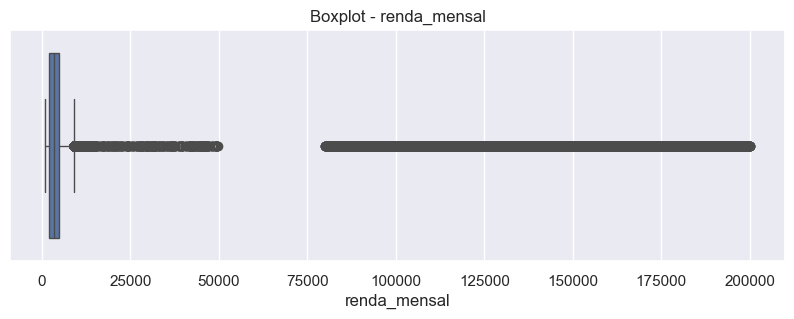


Coluna: valor_compra | min: 15.0 | max: 9999.973194647073 | mean: 182.90 | median: 98.94


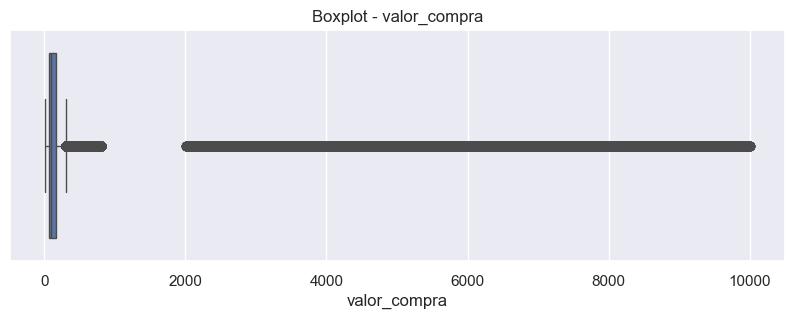


Coluna: frequencia_compras | min: 0.1 | max: 12.0 | mean: 2.35 | median: 1.80


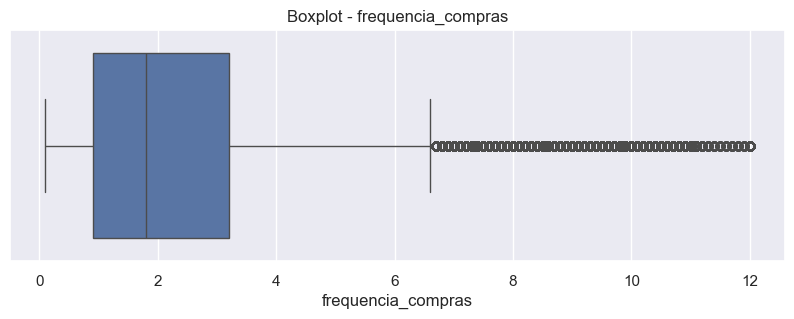


Coluna: n_itens_por_compra | min: 1.0 | max: 15.0 | mean: 7.99 | median: 8.00


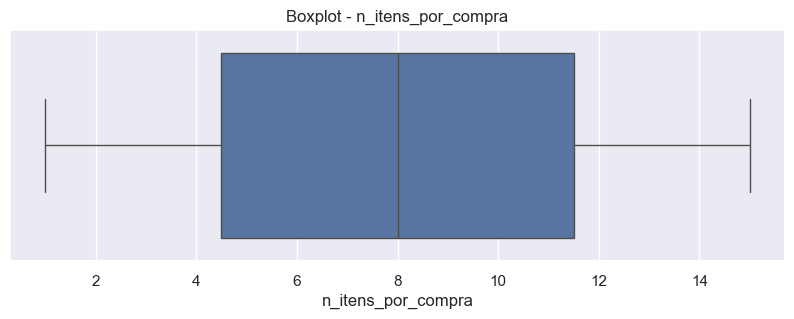


Coluna: score_fidelidade | min: 0.0 | max: 100.0 | mean: 22.87 | median: 21.50


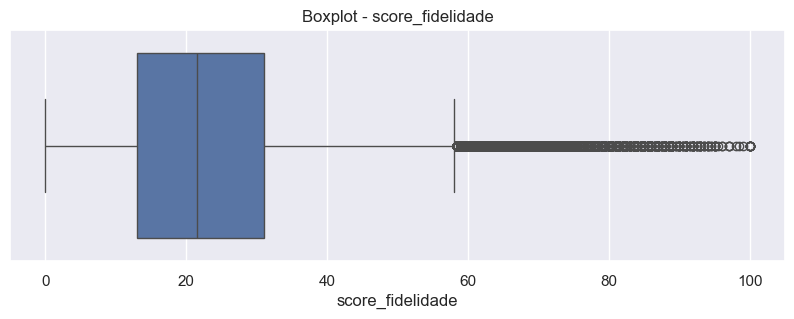


Coluna: desconto_medio | min: 0.0 | max: 25.0 | mean: 12.50 | median: 12.50


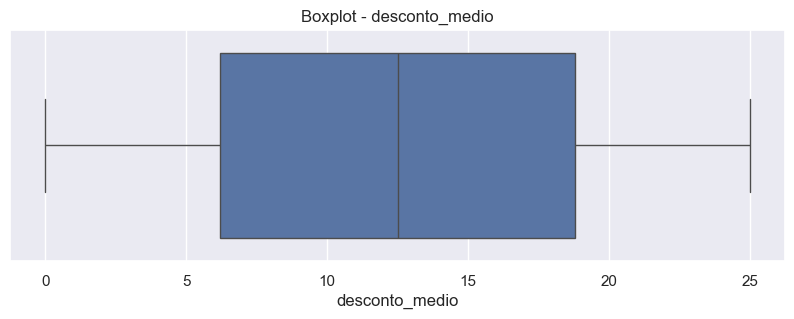


Coluna: prob_churn | min: 0.0 | max: 0.822 | mean: 0.38 | median: 0.42


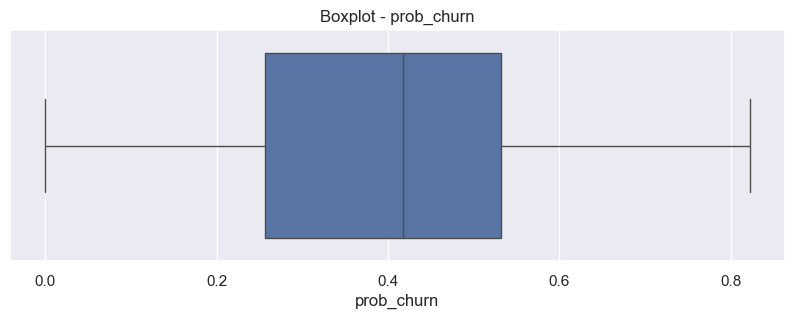

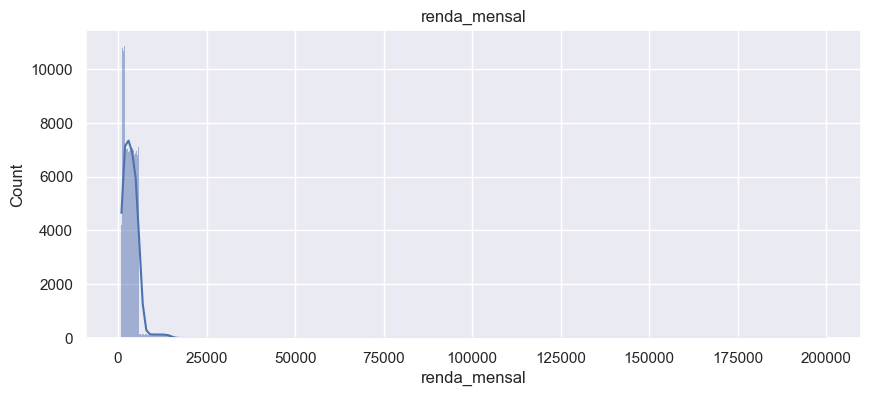

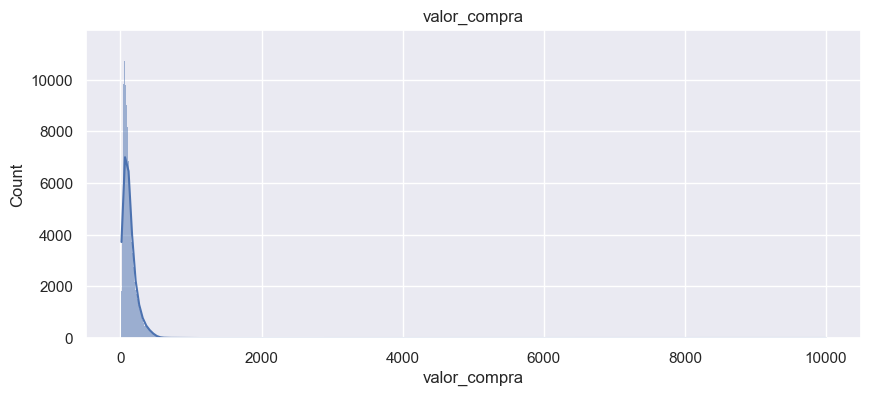

In [16]:
# 5) Range e detecção de outliers
# Verificar negativos e zeros em colunas esperadas
check_cols = ['renda_mensal','valor_compra','frequencia_compras','n_itens_por_compra','score_fidelidade','desconto_medio','prob_churn']
present = [c for c in check_cols if c in df.columns]

for c in present:
    s = df[c].dropna()
    print(f"\nColuna: {c} | min: {s.min()} | max: {s.max()} | mean: {s.mean():.2f} | median: {s.median():.2f}")
    plt.figure(figsize=(10,3))
    sns.boxplot(x=s)
    plt.title(f'Boxplot - {c}')
    plt.show()

# Histograma para renda_mensal e valor_compra
for c in ['renda_mensal','valor_compra']:
    if c in df.columns:
        plt.figure(figsize=(10,4))
        sns.histplot(df[c].dropna(), kde=True)
        plt.title(c)
        plt.show()

### Análise de Outliers

- **Renda mensal e Valor de compra:** Há presença de outliers relevantes, conforme evidenciado nos boxplots e histogramas. É recomendado tratar esses valores para evitar distorções nas análises e modelos.
  
- **Demais variáveis:** Mantêm distribuição consistente, sem indícios significativos de outliers.




gasto_mensal_est criado


count    588128.000000
mean        410.327151
std        1909.932935
min           1.500000
25%          82.180750
50%         177.597000
75%         356.841000
max      101257.400489
Name: gasto_mensal_est, dtype: float64

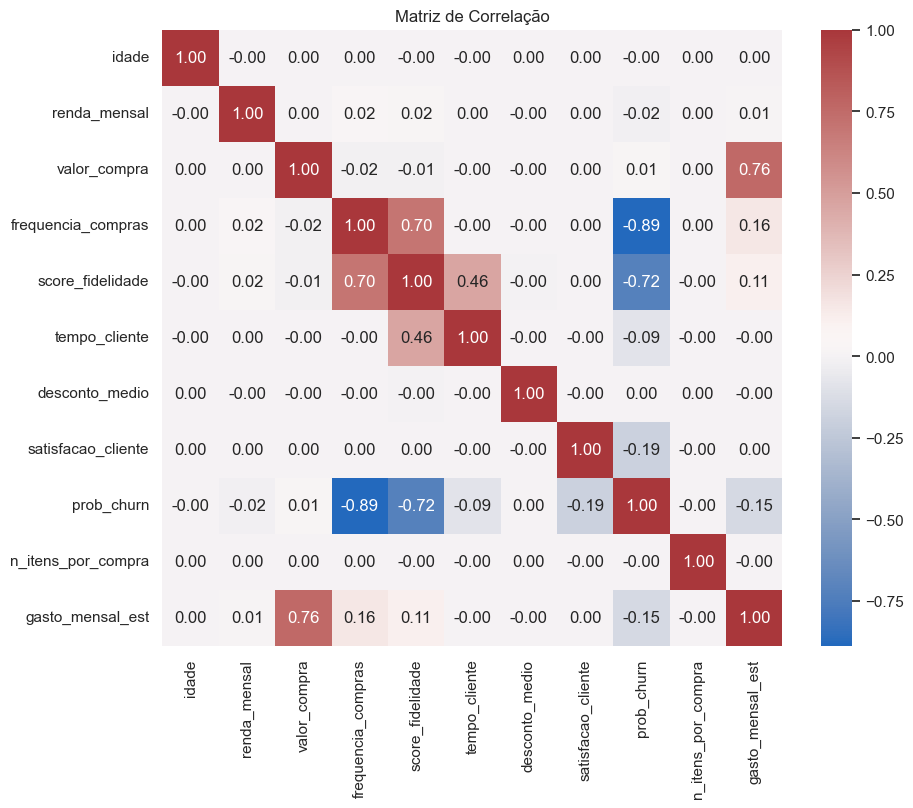

In [11]:
# 6) Relações entre variáveis e vendas
# Criar feature estimada: gasto_mensal = valor_compra * frequencia_compras (se existirem)
if 'valor_compra' in df.columns and 'frequencia_compras' in df.columns:
    df['gasto_mensal_est'] = df['valor_compra'] * df['frequencia_compras']
    print('gasto_mensal_est criado')
    display(df['gasto_mensal_est'].describe())

# Correlação entre variáveis numéricas (inclui gasto_mensal_est se criado)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='vlag')
plt.title('Matriz de Correlação')
plt.show()



feature estimada: gasto_mensal = valor_compra * frequencia_compras

### Análise da Matriz de Correlação

- **Frequência de compras x Probabilidade de churn:** Forte correlação negativa (-0.89).  
  → Quanto mais o cliente compra, **menor a chance de churn**.

- **Score de fidelidade x Probabilidade de churn:** Correlação negativa significativa (-0.72).  
  → Clientes mais fiéis têm **risco muito menor de abandono**.

- **Valor de compra x Gasto mensal estimado:** Correlação alta (0.76).  
  → Clientes que realizam compras de maior valor tendem a ter um gasto mensal mais elevado.

- **Tempo de cliente x Score de fidelidade:** Correlação moderada (0.46).  
  → Clientes antigos tendem a apresentar maior fidelidade.

- **Satisfação do cliente:** Correlações baixas com outras variáveis.  
  → Indica que a satisfação depende de fatores não diretamente representados no dataset.

- **Idade, renda e número de itens por compra:** Baixa correlação com as demais variáveis.  
  → Não se mostram determinantes para o comportamento analisado.

---

#### **Insight**
Os principais direcionadores de churn são **frequência de compras** e **fidelidade**.  
Iniciativas de retenção devem priorizar o aumento de engajamento e fortalecimento da relação com o cliente, mais do que características demográficas ou valor isolado de compra.


In [12]:
# 7) Análise temporal — Recência e Sazonalidade
# Converter data_ultima_compra e calcular recência em dias até a última data do dataset
df['data_ultima_compra'] = pd.to_datetime(
    df['data_ultima_compra'],
    errors='coerce'  # valores inválidos viram NaT
)

if 'data_ultima_compra' in df.columns:
    
    df['_mes'] = df['data_ultima_compra'].dt.to_period('M')
    vendas_mes = df.groupby('_mes').size().reset_index(name='count_clientes')
    vendas_mes['_mes'] = vendas_mes['_mes'].dt.to_timestamp()
    fig = px.line(vendas_mes, x='_mes', y='count_clientes', title='Clientes com última compra por mês')
    fig.show()

### Análise temporal
Observa-se um **crescimento acelerado de compras no último trimestre**, o que pode indicar:
- Efetividade de campanhas de marketing
- Sazonalidade do setor de alimentos e bebidas
- Expansão da base de clientes

**Insght:** Investigar se o crescimento é sustentável ou sazonal.

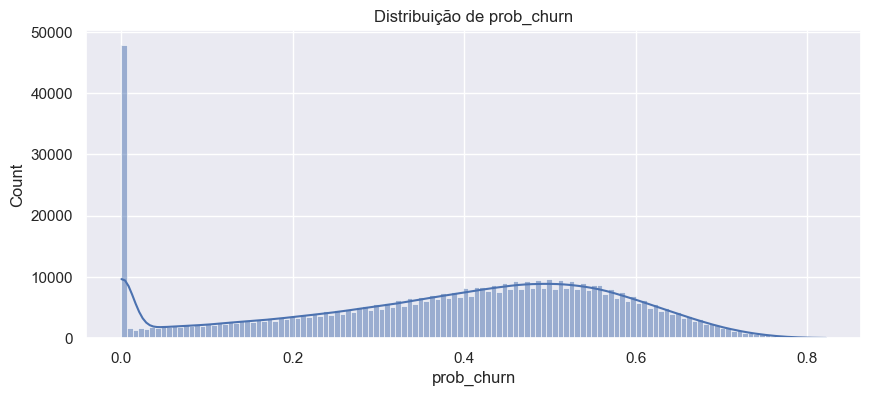

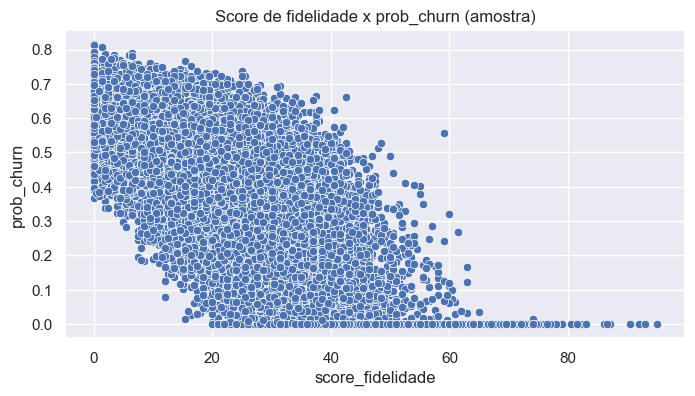

In [13]:
# 9) Marketing, fidelidade e churn


# Probabilidade de churn - distribuição e relação com score_fidelidade
if 'prob_churn' in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df['prob_churn'].dropna(), kde=True)
    plt.title('Distribuição de prob_churn')
    plt.show()
    if 'score_fidelidade' in df.columns:
        plt.figure(figsize=(8,4))
        sns.scatterplot(x='score_fidelidade', y='prob_churn', data=df.sample(20000))
        plt.title('Score de fidelidade x prob_churn (amostra)')
        plt.show()

### Relação Churn e Score fidelidade
 
 Este gráfico confirma uma relação importante: 
 **à medida que aumenta o score de fidelidade, diminui a probabilidade de churn**.

**Insights:**
- Relação negativa esperada e confirmada pelos dados
- Clientes com score de fidelidade alto (>50) têm prob_churn < 0.3
- Oportunidade: aumentar score de fidelidade pode reduzir churn

**Ação recomendada:** Investir em programas de fidelidade para clientes com score baixo.

In [14]:
# 10) Diagnóstico de qualidade dos dados (resumo)
null_pct = (df.isnull().mean()*100).round(2).sort_values(ascending=False)
display(null_pct[null_pct>0])

# Detectar colunas object que aparentam ser numéricas
obj_as_num = []
for c in df.select_dtypes(include='object').columns:
    sample = df[c].dropna().astype(str).head(200)
    try:
        sample.astype(float)
        obj_as_num.append(c)
    except:
        pass
print('\nObject que parecem numéricas (amostra):', obj_as_num)

# Outliers (3 sigma)
outliers = {}
for c in df.select_dtypes(include=[np.number]).columns:
    s = df[c].dropna()
    if s.empty: continue
    mean,std = s.mean(), s.std()
    cnt = ((s>mean+3*std) | (s<mean-3*std)).sum()
    if cnt>0:
        outliers[c]=int(cnt)
print('\nContagem de possíveis outliers (3 sigma):')
display(outliers)

# Sugestão de tratamento (automática, como guia)
summary = []
for c in df.columns:
    issues = []
    sugg = []
    pct_null = (df[c].isnull().mean()*100).round(2)
    if pct_null>0:
        issues.append(f'nulos: {pct_null}%')
        sugg.append('avaliar preenchimento ou remoção')
    if c in outliers:
        issues.append(f'outliers: {outliers[c]}')
        sugg.append('investigar e tratar')
    if c in obj_as_num:
        issues.append('texto formato numérico')
        sugg.append('converter para numérico')
    if issues:
        summary.append({'coluna':c, 'dtype':str(df[c].dtype), 'issues':'; '.join(issues), 'suggestion':'; '.join(sugg)})

summary_df = pd.DataFrame(summary)
if not summary_df.empty:
    display(summary_df)
else:
    print('Nenhum problema crítico detectado automaticamente.')

gasto_mensal_est      1.98
categoria_produto     1.01
canal_compra          1.00
frequencia_compras    1.00
score_fidelidade      1.00
cidade                0.99
valor_compra          0.98
método_pagamento      0.98
renda_mensal          0.97
dtype: float64


Object que parecem numéricas (amostra): []

Contagem de possíveis outliers (3 sigma):


{'renda_mensal': 6055,
 'valor_compra': 5856,
 'frequencia_compras': 10102,
 'score_fidelidade': 4900,
 'tempo_cliente': 3707,
 'gasto_mensal_est': 3929}

,coluna,dtype,issues,suggestion
0,renda_mensal,float64,nulos: 0.97%; outliers: 6055,avaliar preenchimento ou remoção; investigar e...
1,cidade,object,nulos: 0.99%,avaliar preenchimento ou remoção
2,canal_compra,object,nulos: 1.0%,avaliar preenchimento ou remoção
3,categoria_produto,object,nulos: 1.01%,avaliar preenchimento ou remoção
4,valor_compra,float64,nulos: 0.98%; outliers: 5856,avaliar preenchimento ou remoção; investigar e...
5,frequencia_compras,float64,nulos: 1.0%; outliers: 10102,avaliar preenchimento ou remoção; investigar e...
6,score_fidelidade,float64,nulos: 1.0%; outliers: 4900,avaliar preenchimento ou remoção; investigar e...
7,método_pagamento,object,nulos: 0.98%,avaliar preenchimento ou remoção
8,tempo_cliente,int64,outliers: 3707,investigar e tratar
9,gasto_mensal_est,float64,nulos: 1.98%; outliers: 3929,avaliar preenchimento ou remoção; investigar e...


Sugestão - Deixar mais claro o que significam os outputs

In [18]:
from IPython.display import display, Markdown
import numpy as np
import pandas as pd

# =====================================================
# 10) Diagnóstico de Qualidade dos Dados — Resumo
# =====================================================

display(Markdown("## Diagnóstico de Qualidade dos Dados"))

# -----------------------------------------------------
# 1) Percentual de valores nulos por coluna
# -----------------------------------------------------
display(Markdown("### Valores Nulos por Coluna (%)"))

null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct_filtered = null_pct[null_pct > 0]

if not null_pct_filtered.empty:
    display(null_pct_filtered)
else:
    display(Markdown("Não há valores nulos no dataset."))

# -----------------------------------------------------
# 2) Colunas object que aparentam ser numéricas
# -----------------------------------------------------
display(Markdown("### Colunas do tipo texto que aparentam ser numéricas"))

obj_as_num = []
for c in df.select_dtypes(include='object').columns:
    sample = df[c].dropna().astype(str).head(200)
    try:
        sample.astype(float)
        obj_as_num.append(c)
    except:
        pass

if obj_as_num:
    display(pd.DataFrame({'coluna': obj_as_num}))
else:
    display(Markdown("Nenhuma coluna texto aparenta ser numérica."))

# -----------------------------------------------------
# 3) Detecção de outliers (Regra dos 3 sigmas)
# -----------------------------------------------------
display(Markdown("### Possíveis Outliers (Regra dos 3 Sigmas)"))

outliers = {}
for c in df.select_dtypes(include=[np.number]).columns:
    s = df[c].dropna()
    if s.empty:
        continue
    mean, std = s.mean(), s.std()
    cnt = ((s > mean + 3 * std) | (s < mean - 3 * std)).sum()
    if cnt > 0:
        outliers[c] = int(cnt)

if outliers:
    display(
        pd.DataFrame(
            outliers.items(),
            columns=['coluna', 'quantidade_outliers']
        ).sort_values('quantidade_outliers', ascending=False)
    )
else:
    display(Markdown("Nenhum outlier detectado pelo critério de 3 sigmas."))

# -----------------------------------------------------
# 4) Resumo de problemas e sugestões de tratamento
# -----------------------------------------------------
display(Markdown("### Resumo de Problemas Detectados e Sugestões de Tratamento"))

summary = []
for c in df.columns:
    issues = []
    sugg = []

    pct_null = (df[c].isnull().mean() * 100).round(2)
    if pct_null > 0:
        issues.append(f'nulos: {pct_null}%')
        sugg.append('avaliar preenchimento ou remoção')

    if c in outliers:
        issues.append(f'outliers: {outliers[c]}')
        sugg.append('investigar e tratar')

    if c in obj_as_num:
        issues.append('texto em formato numérico')
        sugg.append('converter para numérico')

    if issues:
        summary.append({
            'coluna': c,
            'dtype': str(df[c].dtype),
            'problemas_identificados': '; '.join(issues),
            'sugestao_tratamento': '; '.join(sugg)
        })

summary_df = pd.DataFrame(summary)

if not summary_df.empty:
    display(summary_df)
else:
    display(Markdown("Nenhum problema crítico detectado automaticamente."))


## Diagnóstico de Qualidade dos Dados

### Valores Nulos por Coluna (%)

gasto_mensal_est      1.98
categoria_produto     1.01
canal_compra          1.00
frequencia_compras    1.00
score_fidelidade      1.00
cidade                0.99
valor_compra          0.98
método_pagamento      0.98
renda_mensal          0.97
dtype: float64

### Colunas do tipo texto que aparentam ser numéricas

Nenhuma coluna texto aparenta ser numérica.

### Possíveis Outliers (Regra dos 3 Sigmas)

,coluna,quantidade_outliers
2,frequencia_compras,10102
0,renda_mensal,6055
1,valor_compra,5856
3,score_fidelidade,4900
5,gasto_mensal_est,3929
4,tempo_cliente,3707


### Resumo de Problemas Detectados e Sugestões de Tratamento

,coluna,dtype,problemas_identificados,sugestao_tratamento
0,renda_mensal,float64,nulos: 0.97%; outliers: 6055,avaliar preenchimento ou remoção; investigar e...
1,cidade,object,nulos: 0.99%,avaliar preenchimento ou remoção
2,canal_compra,object,nulos: 1.0%,avaliar preenchimento ou remoção
3,categoria_produto,object,nulos: 1.01%,avaliar preenchimento ou remoção
4,valor_compra,float64,nulos: 0.98%; outliers: 5856,avaliar preenchimento ou remoção; investigar e...
5,frequencia_compras,float64,nulos: 1.0%; outliers: 10102,avaliar preenchimento ou remoção; investigar e...
6,score_fidelidade,float64,nulos: 1.0%; outliers: 4900,avaliar preenchimento ou remoção; investigar e...
7,método_pagamento,object,nulos: 0.98%,avaliar preenchimento ou remoção
8,tempo_cliente,int64,outliers: 3707,investigar e tratar
9,gasto_mensal_est,float64,nulos: 1.98%; outliers: 3929,avaliar preenchimento ou remoção; investigar e...


### Conclusão

Os valores nulos e outliers identificados estão presentes em **baixa quantidade**.  
Sua remoção ou tratamento terá **impacto mínimo no volume de dados** e **não comprometerá a análise de RFM**, garantindo maior qualidade e consistência nos resultados.

Abaixo estão as colunas que serão tratadas e o respectivo tipo de tratamento:

| Coluna              | Tratamento              |
|---------------------|-------------------------|
| renda_mensal        | Nulos e outliers        |
| cidade              | Nulos                   |
| canal_compra        | Nulos                   |
| categoria_produto   | Nulos                   |
| valor_compra        | Nulos e outliers        |
| frequencia_compra   | Nulos                   |
| score_fidelidade    | Nulos                   |
| metodo_pagamento    | Nulos                   |

